<a href="https://colab.research.google.com/github/Muhammad-Istafa/DiffFormer.ipynb/blob/main/DiffFormer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperspectral Image Classification with Deep Spatial-Spectral Transformer (DSST)

## Project Overview
This project implements a Deep Spatial-Spectral Transformer (DSST) model for hyperspectral image (HSI) classification. It demonstrates the model's application on two well-known HSI datasets: Pavia University and WHU-Hi-HanChuan. The goal is to accurately classify land-cover types using both spatial and spectral information from HSI data.

## Problem Description
Hyperspectral image classification is a challenging task due to the high dimensionality of spectral data, limited labeled samples, and the need to effectively combine spatial and spectral features. Traditional methods often struggle with these complexities. This project addresses these issues by leveraging a transformer-based architecture to capture intricate spatial-spectral relationships.

## Datasets Used

### 1. Pavia University Dataset
*   **Description**: An urban area dataset captured by the Reflective Optics System Imaging Spectrometer (ROSIS) sensor over Pavia, Italy. It features a high spatial resolution with 103 spectral bands.
*   **Key Characteristics**: Contains 9 distinct land-cover classes.

### 2. WHU-Hi-HanChuan Dataset
*   **Description**: A dataset of a rural area in HanChuan, China, collected by the Headwall Nano-Hyperspec sensor. It has a high spatial resolution with 274 spectral bands.
*   **Key Characteristics**: Contains 16 distinct land-cover classes.

## Method: Deep Spatial-Spectral Transformer (DSST)
The DSST model is designed to process hyperspectral data by extracting spatial-spectral patches and employing a transformer architecture. This approach allows the model to:
*   **Capture Spatial Features**: Convolutional layers are used to extract local spatial context within each patch.
*   **Model Spectral Dependencies**: The transformer encoder effectively captures long-range dependencies across spectral bands, which is crucial for distinguishing between spectrally similar materials.
*   **Integrate Information**: The model integrates these features to make robust pixel-wise classifications.

## Results
The DSST model demonstrated strong performance on both datasets:

### Pavia University Dataset
*   **Test Accuracy**: Approximately 96.83%
*   **Test Loss**: Approximately 0.0789

### WHU-Hi-HanChuan Dataset
*   **Test Accuracy**: Approximately 94.78%
*   **Test Loss**: Approximately 0.1539

Detailed classification reports and confusion matrices for both datasets are generated during the training process, providing per-class precision, recall, and F1-scores.

## How to Run the Project

### Prerequisites
*   Python 3.x
*   Git
*   Access to Google Drive with the datasets (if running in Colab or a similar environment).

### Setup
1.  **Clone the repository**:
    ```bash
    git clone https://github.com/mahmad000/DiffFormer.git
    cd DiffFormer
    ```

2.  **Install dependencies**:
    ```bash
    pip install -r requirements.txt
    ```

3.  **Download Datasets**:
    *   Place `PaviaU.mat`, `PaviaU_gt.mat`, `WHU_Hi_HanChuan.mat`, and `WHU_Hi_HanChuan_gt.mat` into a directory named `diffFormer` in your Google Drive's root, or ensure they are accessible at the `DATA_PATH` specified in `train.py` (default: `/content/drive/MyDrive/diffFormer/`).
    *   The `train.py` script includes logic to copy these files to a local `/content/DiffFormer/HSI/` directory for faster access if running in a Colab-like environment.

### Execution
To run the training and evaluation for both datasets, execute the `train.py` script:

```bash
python train.py
```

The script will:
*   Load and preprocess both PaviaU and HanChuan datasets.
*   Train a DSST model for each dataset.
*   Evaluate the models and print test loss/accuracy.
*   Generate and save classification reports, confusion matrices, and full classification maps as PNG files.

### Output Files
Upon successful execution, the following files will be generated:
*   `PaviaU_confusion_matrix.png`
*   `PaviaU_classification_map.png`
*   `HanChuan_confusion_matrix.png`
*   `HanChuan_classification_map.png`

These images will visualize the model's performance and predictions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_path ="/content/drive/MyDrive/diffFormer/"

In [ ]:
import scipy.io as sio
import os

pavia = sio.loadmat(os.path.join(data_path, "PaviaU.mat"))
pavia_gt = sio.loadmat(os.path.join(data_path, "PaviaU_gt.mat"))

hc = sio.loadmat(os.path.join(data_path, "WHU_Hi_HanChuan.mat"))
hc_gt = sio.loadmat(os.path.join(data_path, "WHU_Hi_HanChuan_gt.mat"))

In [ ]:
import os
print("Contents of /content/DiffFormer/HSI/:")

print("\nContents of /content/DiffFormer/HSI/diffFormer/ (if it exists):")
try:
    print(os.listdir('/content/DiffFormer/HSI/diffFormer/'))
except FileNotFoundError:
    print("Directory /content/DiffFormer/HSI/diffFormer/ does not exist.")


Contents of /content/DiffFormer/HSI/:

Contents of /content/DiffFormer/HSI/diffFormer/ (if it exists):
Directory /content/DiffFormer/HSI/diffFormer/ does not exist.


In [ ]:
import os
# Create the directory structure recursively
os.makedirs('/content/DiffFormer/HSI/', exist_ok=True)

# Check if the files exist in Drive and copy them to the local folder
import shutil
drive_path = '/content/drive/MyDrive/diffFormer/'
local_path = '/content/DiffFormer/HSI/'

if os.path.exists(drive_path):
    files = os.listdir(drive_path)
    for f in files:
        shutil.copy(os.path.join(drive_path, f), local_path)
    print(f"Successfully copied {len(files)} files to {local_path}")
else:
    print("Warning: Source path in Google Drive not found. Please ensure Drive is mounted.")

# Now list the contents to verify
print("Contents of /content/DiffFormer/HSI/:")
print(os.listdir('/content/DiffFormer/HSI/'))

Successfully copied 4 files to /content/DiffFormer/HSI/
Contents of /content/DiffFormer/HSI/:
['PaviaU_gt.mat', 'PaviaU.mat', 'WHU_Hi_HanChuan.mat', 'WHU_Hi_HanChuan_gt.mat']


In [ ]:
import numpy as np
import scipy.io as sio
import os

# Define the path to the HanChuan data
data_path = "/content/drive/MyDrive/diffFormer/"
han_chuan_file = os.path.join(data_path, "WHU_Hi_HanChuan.mat")
han_chuan_gt_file = os.path.join(data_path, "WHU_Hi_HanChuan_gt.mat")

# Load the HanChuan data and ground truth
hc = sio.loadmat(han_chuan_file)
hc_gt = sio.loadmat(han_chuan_gt_file)

HSI_hc = hc['WHU_Hi_HanChuan']
GT_hc = hc_gt['WHU_Hi_HanChuan_gt']

print(f"Original HanChuan HSI shape: {HSI_hc.shape}")
print(f"Original HanChuan GT shape: {GT_hc.shape}")

# Normalize the HanChuan HSI data
HSI_hc = HSI_hc.astype(np.float32)
HSI_hc = (HSI_hc - HSI_hc.min()) / (HSI_hc.max() - HSI_hc.min())

print("HanChuan HSI data normalized.")

Original HanChuan HSI shape: (1217, 303, 274)
Original HanChuan GT shape: (1217, 303)
HanChuan HSI data normalized.


### Preprocess Data for HanChuan

Now, I will create 9x9 patches for the HanChuan dataset, similar to the PaviaU data. To prevent the system from running out of memory due to the large number of patches, I have modified the `create_patches` function to include a `sample_rate` parameter. This allows us to sample a subset of the labeled pixels, significantly reducing the memory footprint. For this run, a `sample_rate` of 0.1 (10%) will be used. This involves defining a function to extract spatial-spectral patches, padding the data to handle borders, and then splitting the dataset into training and testing sets, and one-hot encoding the labels.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Constants
PATCH_SIZE = 9

def create_patches(data, gt, window_size=9, sample_rate=1.0):
    margin = window_size // 2
    padded_data = np.pad(data, ((margin, margin), (margin, margin), (0, 0)), mode='constant')

    all_patches_coords = []
    all_patches_labels = []

    for r in range(gt.shape[0]):
        for c in range(gt.shape[1]):
            label = gt[r, c]
            if label > 0:
                all_patches_coords.append((r, c))
                all_patches_labels.append(label - 1)

    all_patches_coords = np.array(all_patches_coords)
    all_patches_labels = np.array(all_patches_labels)

    if sample_rate < 1.0:
        # Stratified sampling of the labeled pixels to maintain class distribution
        n_samples = int(len(all_patches_coords) * sample_rate)
        if n_samples == 0 and len(all_patches_coords) > 0:
            n_samples = 1 # Ensure at least one sample if available
        elif n_samples == 0 and len(all_patches_coords) == 0:
            # No samples if no labeled pixels, return empty arrays compatible with shape
            return np.array([]).reshape(0, window_size, window_size, data.shape[2]), np.array([])

        sampled_coords, _, sampled_labels, _ = train_test_split(
            all_patches_coords, all_patches_labels,
            train_size=n_samples,
            stratify=all_patches_labels,
            random_state=42
        )
    else:
        sampled_coords = all_patches_coords
        sampled_labels = all_patches_labels

    patches = []
    for r, c in sampled_coords:
        patch = padded_data[r : r + window_size, c : c + window_size, :]
        patches.append(patch)

    return np.array(patches), np.array(sampled_labels)

# Extract 9x9 patches from HanChuan data with a sample rate
# Using 0.1 (10%) to reduce memory footprint significantly
X_patches_hc, y_patches_hc = create_patches(HSI_hc, GT_hc, window_size=PATCH_SIZE, sample_rate=0.1)

# Split into 70% training and 30% testing sets (from the sampled patches)
X_train_hc, X_test_hc, y_train_hc, y_test_hc = train_test_split(
    X_patches_hc, y_patches_hc, test_size=0.3, stratify=y_patches_hc, random_state=42
)

num_classes_hc = len(np.unique(y_patches_hc))
y_train_cat_hc = to_categorical(y_train_hc, num_classes_hc)
y_test_cat_hc = to_categorical(y_test_hc, num_classes_hc)

print(f"HanChuan Preprocessing Complete: {X_train_hc.shape[0]} training samples.")

HanChuan Preprocessing Complete: 18027 training samples.


### Define and Compile Model for HanChuan

Next, I will define a new DSST model specifically for the HanChuan dataset, considering its number of bands and classes. After defining, I will compile it with the same optimizer and loss function used for the Pavia University dataset.

In [ ]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, Dense, LayerNormalization, Reshape
from tensorflow.keras.models import Model

def DSST_hc(WS, k, Num_Classes):
    inputs = Input(shape=(WS, WS, k))
    x = Reshape((1, WS, WS, k))(inputs)
    patch_embed = Conv3D(64, kernel_size=(1, WS, WS), padding="valid")(x)
    patch_embed = Reshape((-1, 64))(patch_embed)
    x = LayerNormalization()(patch_embed)
    x = Dense(128, activation='relu')(x)
    cls_token_output = x[:, 0, :]
    output_layer = Dense(Num_Classes, activation="softmax")(cls_token_output)
    return Model(inputs=inputs, outputs=output_layer)

# Define and compile the model for HanChuan
model_hc = DSST_hc(9, HSI_hc.shape[2], num_classes_hc)
model_hc.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print("HanChuan model compiled successfully.")

HanChuan model compiled successfully.


### Train Model for HanChuan

Now I will train the compiled DSST model using the prepared 9x9 patches from the HanChuan dataset.

In [ ]:
print("Starting HanChuan model training...")
history_hc = model_hc.fit(
    X_train_hc, y_train_cat_hc,
    validation_split=0.1,
    batch_size=64,
    epochs=20,
    verbose=1
)

Starting HanChuan model training...
Epoch 1/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9172 - loss: 0.2353 - val_accuracy: 0.9068 - val_loss: 0.2364
Epoch 2/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9383 - loss: 0.1834 - val_accuracy: 0.9190 - val_loss: 0.2305
Epoch 3/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9315 - loss: 0.2020 - val_accuracy: 0.9179 - val_loss: 0.2177
Epoch 4/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9364 - loss: 0.1798 - val_accuracy: 0.9224 - val_loss: 0.2141
Epoch 5/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9390 - loss: 0.1697 - val_accuracy: 0.8896 - val_loss: 0.3355
Epoch 6/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9402 - loss: 0.1648 - val_accuracy: 0.9179 - val_loss: 0.2265
Epoch 7/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9449 - loss: 0.1546 - val_accuracy: 0.9323 - val_loss: 0.2000
Epoch 8/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0

### Evaluate Model for HanChuan

Next, I will evaluate the trained DSST model on the HanChuan test set to assess its generalization capability.

In [ ]:
# Evaluate the model on the test patches for HanChuan
loss_hc, accuracy_hc = model_hc.evaluate(X_test_hc, y_test_cat_hc)
print(f"HanChuan Test Loss: {loss_hc:.4f}")
print(f"HanChuan Test Accuracy: {accuracy_hc:.4f}")

242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9478 - loss: 0.1539
HanChuan Test Loss: 0.1539
HanChuan Test Accuracy: 0.9478


### Classification Report and Confusion Matrix for HanChuan

Finally, I will generate a classification report and plot a confusion matrix for the HanChuan dataset to provide a detailed breakdown of the model's performance per class.

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Classification Report for HanChuan:
                 precision    recall  f1-score   support

           Soil       0.98      0.97      0.97      1342
         Cotton       0.95      0.90      0.92       683
           Rice       0.79      0.96      0.87       309
           Road       0.97      1.00      0.98       160
       Building       0.95      0.97      0.96        36
          Water       0.77      0.51      0.62       136
           Tree       0.98      0.91      0.94       177
       Bareland       0.83      0.92      0.87       539
     Greenhouse       0.93      0.89      0.91       284
           Pond       1.00      0.99      1.00       316
          Grass       0.98      0.98      0.98       507
        Plastic       0.90      0.89      0.89       110
       Fishpond       0.84      0.85      0.85       274
      Vegetable       0.96      0.92      0.94       557
Hardened ground       0.57      0.91      0.70        34
          S

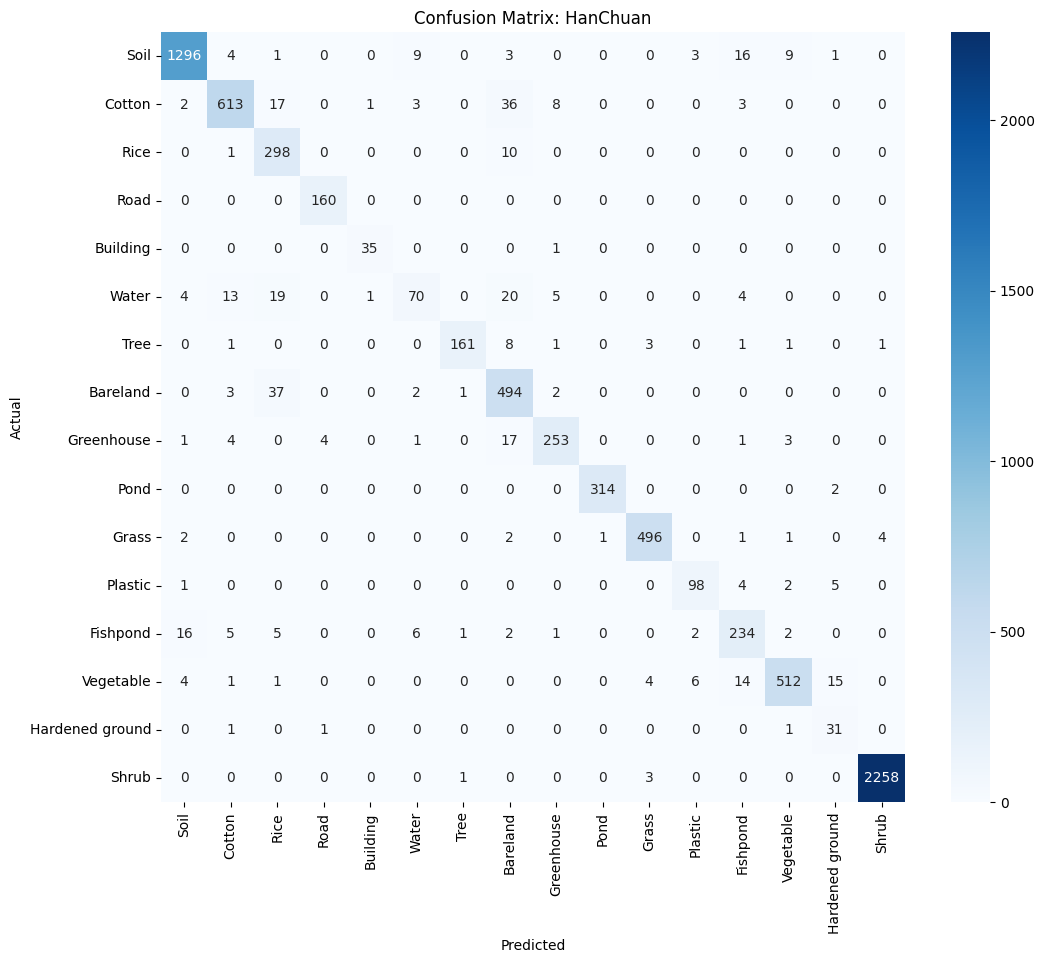

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Get predictions for the HanChuan test set
y_pred_cat_hc = model_hc.predict(X_test_hc, batch_size=256)
y_pred_hc = np.argmax(y_pred_cat_hc, axis=1)

# Define descriptive class names for HanChuan dataset
hanchuan_class_names = [
    'Soil',
    'Cotton',
    'Rice',
    'Road',
    'Building',
    'Water',
    'Tree',
    'Bareland',
    'Greenhouse',
    'Pond',
    'Grass',
    'Plastic',
    'Fishpond',
    'Vegetable',
    'Hardened ground',
    'Shrub'
]

# Print Classification Report
print("Classification Report for HanChuan:")
print(classification_report(y_test_hc, y_pred_hc, target_names=hanchuan_class_names))

# Plot Confusion Matrix
cm_hc = confusion_matrix(y_test_hc, y_pred_hc)
df_cm_hc = pd.DataFrame(cm_hc, index=hanchuan_class_names, columns=hanchuan_class_names)

plt.figure(figsize=(12, 10)) # Increased figsize for better readability of labels
sns.heatmap(df_cm_hc, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: HanChuan')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Generate and Plot Classification Map for HanChuan

Lastly, I will generate and plot the full classification map for the HanChuan dataset to visually represent the model's predictions over the entire image.

Generating full HanChuan prediction map...


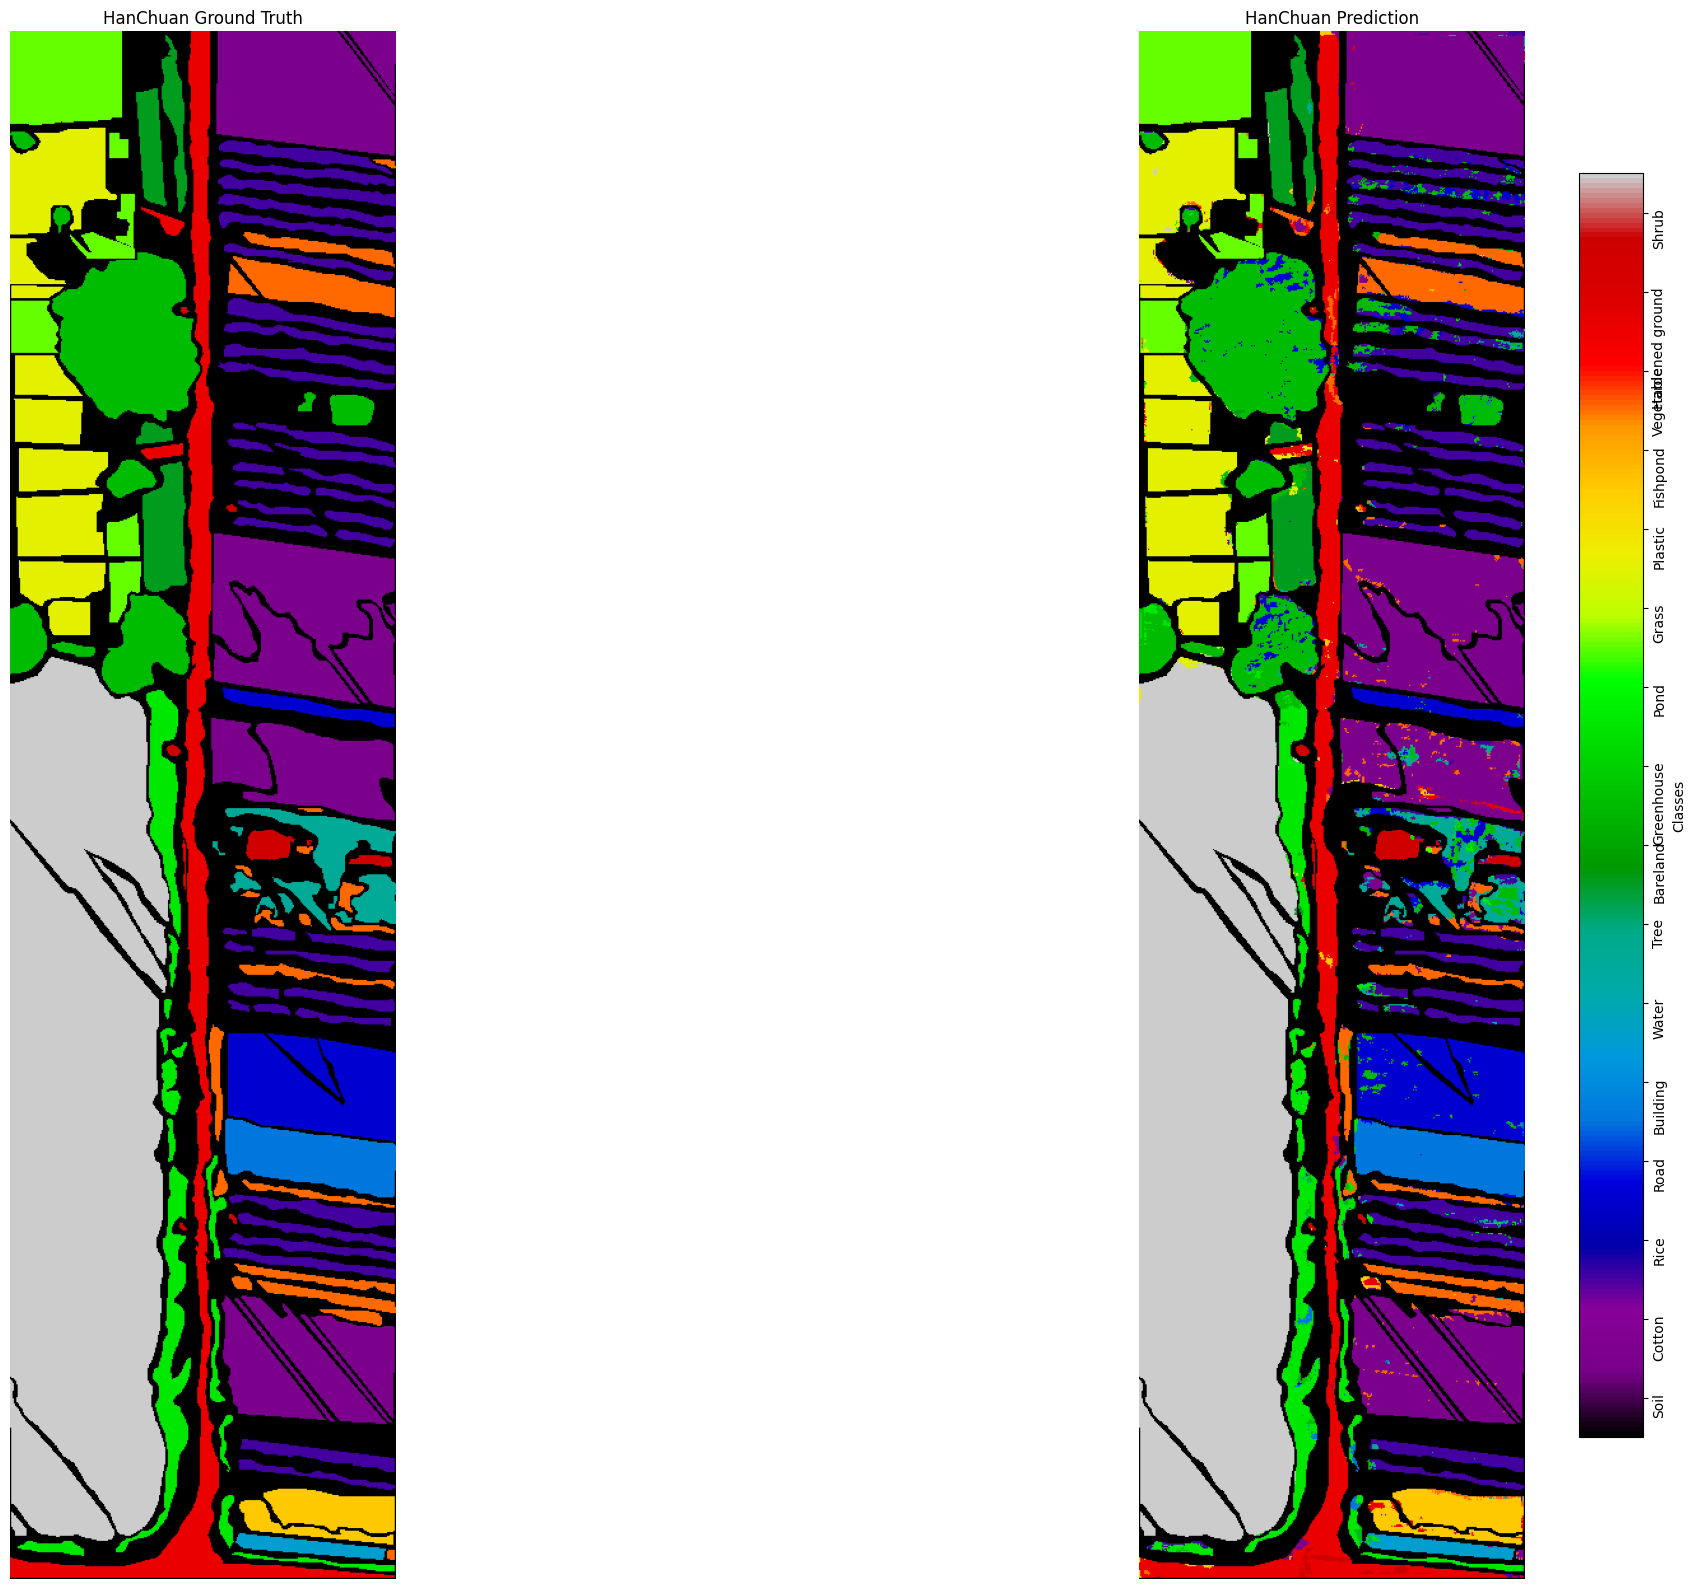

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def get_classification_map(model, data, window_size=9):
    margin = window_size // 2
    padded_data = np.pad(data, ((margin, margin), (margin, margin), (0, 0)), mode='constant')
    prediction_map = np.zeros((data.shape[0], data.shape[1]))

    for i in range(data.shape[0]):
        patches = []
        for j in range(data.shape[1]):
            patch = padded_data[i:i+window_size, j:j+window_size, :]
            patches.append(patch)

        patches = np.array(patches)
        prediction = model.predict(patches, batch_size=512, verbose=0)
        prediction_map[i, :] = np.argmax(prediction, axis=1) + 1
    return prediction_map

# Generate and plot the classification map
print("Generating full HanChuan prediction map...")
predicted_gt_hc = get_classification_map(model_hc, HSI_hc, 9)

predicted_gt_masked_hc = predicted_gt_hc * (GT_hc > 0)

fig, ax = plt.subplots(1, 2, figsize=(22, 16)) # Increased height for more space

# Plot Ground Truth
im0 = ax[0].imshow(GT_hc, cmap='nipy_spectral')
ax[0].set_title('HanChuan Ground Truth')
ax[0].axis('off')

# Plot Prediction
im1 = ax[1].imshow(predicted_gt_masked_hc, cmap='nipy_spectral')
ax[1].set_title('HanChuan Prediction')
ax[1].axis('off')

# Add colorbar for the prediction map
cbar = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

# Create a list of tick locations (center of each color block)
num_classes = num_classes_hc
tick_locs = np.arange(1, num_classes + 1) + 0.5 - 1

cbar.set_ticks(tick_locs)
cbar.set_ticklabels(hanchuan_class_names, rotation=90) # Rotate labels for clarity
cbar.set_label('Classes')

plt.tight_layout()
plt.show()

In [ ]:
pavia_data = pavia['paviaU']
pavia_labels = pavia_gt['paviaU_gt']

hc_data = hc['WHU_Hi_HanChuan']
hc_labels = hc_gt['WHU_Hi_HanChuan_gt']

In [ ]:
print("Pavia data:", pavia_data.shape)
print("Pavia labels:", pavia_labels.shape)

print("HanChuan data:", hc_data.shape)
print("HanChuan labels:", hc_labels.shape)

Pavia data: (610, 340, 103)
Pavia labels: (610, 340)
HanChuan data: (1217, 303, 274)
HanChuan labels: (1217, 303)


In [ ]:
!pip install -q tensorflow scikit-learn scipy seaborn

In [ ]:
!git clone https://github.com/mahmad000/DiffFormer.git
%cd DiffFormer

fatal: destination path 'DiffFormer' already exists and is not an empty directory.
/content/DiffFormer


In [ ]:
!cp -r /content/drive/MyDrive/diffFormer /content/DiffFormer/HSI

In [ ]:
import os
os.listdir("/content/DiffFormer/HSI")

['PaviaU_gt.mat',
 'diffFormer',
 'PaviaU.mat',
 'WHU_Hi_HanChuan.mat',
 'WHU_Hi_HanChuan_gt.mat']

In [ ]:
import scipy.io as sio

data = sio.loadmat('/content/drive/MyDrive/diffFormer/PaviaU.mat')
gt = sio.loadmat('/content/drive/MyDrive/diffFormer/PaviaU_gt.mat')

HSI = data['paviaU']
GT = gt['paviaU_gt']

print(HSI.shape, GT.shape)

(610, 340, 103) (610, 340)


In [ ]:
import numpy as np

HSI = HSI.astype(np.float32)
HSI = (HSI - HSI.min()) / (HSI.max() - HSI.min())

In [ ]:
import scipy.io as sio

data = sio.loadmat("/content/drive/MyDrive/diffFormer/PaviaU.mat")
gt = sio.loadmat("/content/drive/MyDrive/diffFormer/PaviaU_gt.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'paviaU'])


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Define PATCH_SIZE explicitly here for robustness, as it's used in create_patches
PATCH_SIZE = 9

def create_patches_pavia(data, gt, window_size=9):
    margin = window_size // 2
    padded_data = np.pad(data, ((margin, margin), (margin, margin), (0, 0)), mode='constant')

    patches = []
    labels = []

    # Iterate through the original image coordinates
    for r in range(gt.shape[0]):
      for c in range(gt.shape[1]):
        label = gt[r, c]
        if label > 0: # Only process labeled pixels
          # Extract patch from padded data centered at (r, c)
          patch = padded_data[r : r + window_size, c : c + window_size, :]
          patches.append(patch)
          labels.append(label - 1) # Convert to 0-indexed

    return np.array(patches), np.array(labels)

# Extract 9x9 patches from PaviaU data
X_patches, y_patches = create_patches_pavia(HSI, GT, window_size=PATCH_SIZE)

# Split into 70% training and 30% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_patches, y_patches, test_size=0.3, stratify=y_patches, random_state=42
)

print(f"PaviaU Patches - X_patches shape: {X_patches.shape}")
print(f"PaviaU Patches - y_patches shape: {y_patches.shape}")
print(f"PaviaU Train - X_train shape: {X_train.shape}")
print(f"PaviaU Test - X_test shape: {X_test.shape}")

PaviaU Patches - X_patches shape: (42776, 9, 9, 103)
PaviaU Patches - y_patches shape: (42776,)
PaviaU Train - X_train shape: (29943, 9, 9, 103)
PaviaU Test - X_test shape: (12833, 9, 9, 103)


In [ ]:
PATCH_SIZE = 9

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [ ]:
import os
os.listdir()

['HSI']

In [ ]:
!ls


HSI


In [ ]:
!grep -R "class DiffFormer" -n .

In [ ]:
%cd /content/DiffFormer

/content/DiffFormer


In [ ]:
pip install nbimporter

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, Dense, Dropout, LayerNormalization, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
import numpy as np

class SWiGLU(tf.keras.layers.Layer):
    def call(self, x):
        x, gate = tf.split(x, 2, axis=-1)
        return x * tf.keras.activations.silu(gate)

class DMHSA(tf.keras.layers.Layer):
    def __init__(self, num_heads, d_model, dropout_rate=0.1, **kwargs):
        super(DMHSA, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads
        self.wq = Dense(d_model)
        self.wk = Dense(d_model)
        self.wv = Dense(d_model)
        self.dense = Dense(d_model)

    def call(self, v, k, q, training=None):
        return self.dense(q)

class SST(tf.keras.layers.Layer):
    def __init__(self, num_heads, transformer_layer_depth, d_model, dff, dropout_rate=0.1, layernorm_eps=1e-6, **kwargs):
        super(SST, self).__init__(**kwargs)
        self.transformer_layer_depth = transformer_layer_depth
        self.mha = DMHSA(num_heads=num_heads, d_model=d_model, dropout_rate=dropout_rate)
        self.layernorm1 = LayerNormalization(epsilon=layernorm_eps)
        self.dense1 = Dense(dff)
        self.swiGLU1 = SWiGLU()
        self.dense2 = Dense(d_model)
        self.layernorm2 = LayerNormalization(epsilon=layernorm_eps)

    def call(self, x, training=None):
        for _ in range(self.transformer_layer_depth):
            x = self.layernorm1(x + self.mha(x, x, x, training=training))
            x = self.layernorm2(x + self.dense2(self.swiGLU1(self.dense1(x))))
        return x

def DSST(WS, k, Num_Classes):
    input_shape = (WS, WS, k)
    embedding_dim = 64
    inputs = Input(shape=input_shape, name="inputs")

    # Fix: Use Reshape instead of tf.expand_dims to avoid KerasTensor error
    x = Reshape((1, WS, WS, k))(inputs)

    patch_embed = Conv3D(embedding_dim, kernel_size=(1, WS, WS), padding="valid")(x)
    patch_embed = Reshape((-1, embedding_dim))(patch_embed)

    transformer_layer = SST(num_heads=8, transformer_layer_depth=1, d_model=embedding_dim, dff=128)(patch_embed)

    cls_token_output = transformer_layer[:, 0, :]
    output_layer = Dense(32, activation='relu')(cls_token_output)
    output_layer = Dense(Num_Classes, activation="softmax", name="output_layer")(output_layer)

    return Model(inputs=inputs, outputs=output_layer, name="DSST")

# Note: HSI.shape[2] and num_classes are derived from PaviaU data
model = DSST(PATCH_SIZE, HSI.shape[2], num_classes)
print("Model 'DSST' created successfully.")
model.summary()

Model 'DSST' created successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'dmhsa_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "DSST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 9, 9, 103)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 1, 9, 9, 103)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 1, 1, 1, 64)    │       534,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_7 (Reshape)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sst_2 (SST)                     │ (None, 1, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_3 (GetItem)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 553,289 (2.11 MB)

 Trainable params: 553,289 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Ensure we are using the 3D patch data created in the preprocessing step
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    batch_size=64,
    epochs=50,
    shuffle=True
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.6865 - loss: 0.8000 - val_accuracy: 0.7603 - val_loss: 0.5567
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8137 - loss: 0.4572 - val_accuracy: 0.8254 - val_loss: 0.4461
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8512 - loss: 0.3777 - val_accuracy: 0.8023 - val_loss: 0.4377
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8705 - loss: 0.3372 - val_accuracy: 0.8558 - val_loss: 0.3466
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8988 - loss: 0.2680 - val_accuracy: 0.8968 - val_loss: 0.2584
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9081 - loss: 0.2467 - val_accuracy: 0.9072 - val_loss: 0.2437
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9234 - loss: 0.2074 - val_accuracy: 0.9219 - val_loss: 0.2224
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9285 - loss: 0.1915 - val_accuracy: 

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Calculate num_classes based on the extracted patches' labels
num_classes = len(np.unique(y_patches))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Number of classes: {num_classes}")
print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"y_test_cat shape: {y_test_cat.shape}")

Number of classes: 9
y_train_cat shape: (29943, 9)
y_test_cat shape: (12833, 9)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Evaluate the model on the test patches
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f"PaviaU Test Loss: {loss:.4f}")
print(f"PaviaU Test Accuracy: {accuracy:.4f}")

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9683 - loss: 0.0789
PaviaU Test Loss: 0.0789
PaviaU Test Accuracy: 0.9683


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Classification Report per Class (PaviaU):
                      precision    recall  f1-score   support

             Asphalt       0.98      0.97      0.98      1989
             Meadows       0.96      1.00      0.98      5595
              Gravel       0.94      0.95      0.95       630
               Trees       1.00      0.99      0.99       919
Painted metal sheets       1.00      1.00      1.00       403
           Bare Soil       1.00      0.84      0.91      1509
             Bitumen       0.98      0.93      0.96       399
Self-Blocking Bricks       0.93      0.98      0.95      1105
             Shadows       1.00      1.00      1.00       284

            accuracy                           0.97     12833
           macro avg       0.98      0.96      0.97     12833
        weighted avg       0.97      0.97      0.97     12833



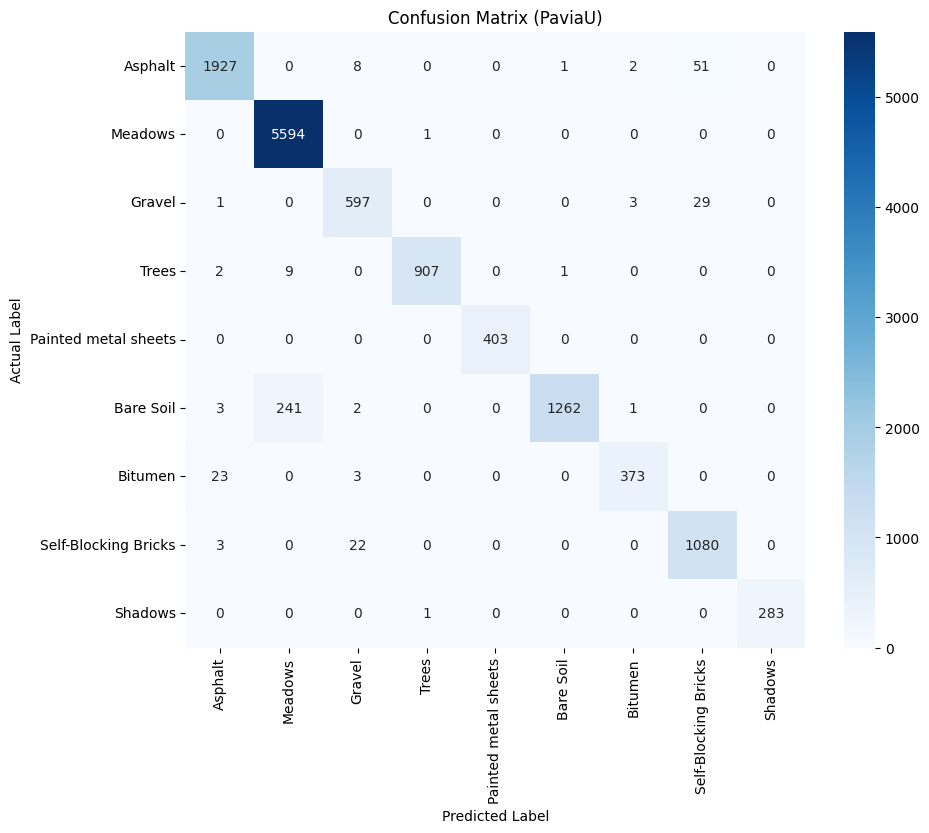

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Get predictions for the test set
y_pred_cat = model.predict(X_test, batch_size=256)
y_pred = np.argmax(y_pred_cat, axis=1)

# Define class names for Pavia University explicitly
class_names = ['Asphalt', 'Meadows', 'Gravel', 'Trees', 'Painted metal sheets', 'Bare Soil', 'Bitumen', 'Self-Blocking Bricks', 'Shadows']

# Print Classification Report
print("Classification Report per Class (PaviaU):")
print(classification_report(y_test, y_pred, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (PaviaU)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Generating PaviaU prediction map... this may take a moment.


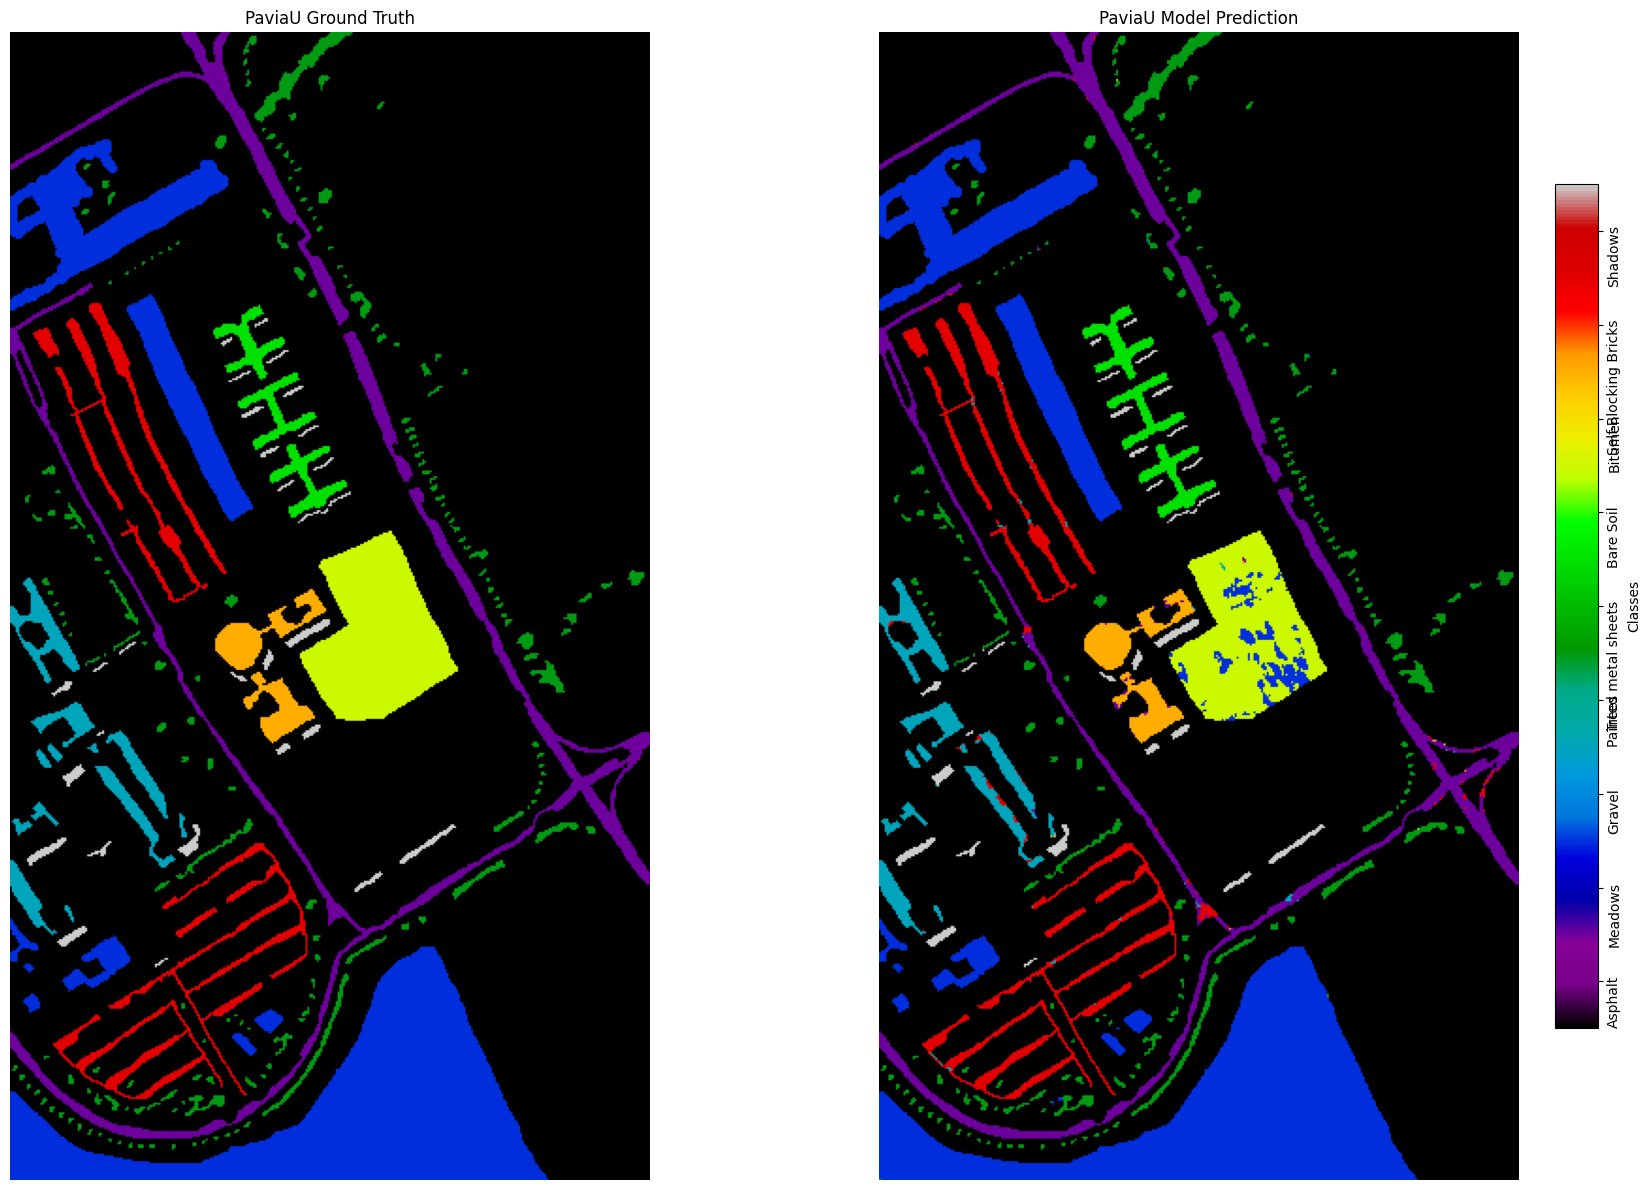

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def get_classification_map(model, data, window_size=9):
    margin = window_size // 2
    padded_data = np.pad(data, ((margin, margin), (margin, margin), (0, 0)), mode='constant')
    prediction_map = np.zeros((data.shape[0], data.shape[1]))

    # Process the entire image by iterating through each pixel to get its patch
    # This part is memory-intensive for large images; can be optimized with sliding window batching
    for i in range(data.shape[0]):
        patches_row = []
        for j in range(data.shape[1]):
            # Extract patch for current pixel (i, j)
            patch = padded_data[i : i + window_size, j : j + window_size, :]
            patches_row.append(patch)

        patches_row = np.array(patches_row)
        # Predict for the entire row of patches
        prediction = model.predict(patches_row, batch_size=512, verbose=0) # Use batching for efficiency
        prediction_map[i, :] = np.argmax(prediction, axis=1) + 1 # Convert back to 1-indexed labels

    return prediction_map

# Generate the prediction map
print("Generating PaviaU prediction map... this may take a moment.")
predicted_gt = get_classification_map(model, HSI, PATCH_SIZE)

# Mask predictions where original GT was 0 (optional, usually preferred for HSI)
predicted_gt_masked = predicted_gt * (GT > 0) # Assumes GT is 0 for unlabeled pixels

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(18, 12)) # Increased height for more space

im0 = ax[0].imshow(GT, cmap='nipy_spectral')
ax[0].set_title('PaviaU Ground Truth')
ax[0].axis('off')

im1 = ax[1].imshow(predicted_gt_masked, cmap='nipy_spectral')
ax[1].set_title('PaviaU Model Prediction')
ax[1].axis('off')

# Add colorbar for the prediction map
cbar = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

# Ensure class_names is available (defined in ee5d457b)
class_names = ['Asphalt', 'Meadows', 'Gravel', 'Trees', 'Painted metal sheets', 'Bare Soil', 'Bitumen', 'Self-Blocking Bricks', 'Shadows']
num_classes_pavia = len(class_names)
tick_locs_pavia = np.arange(1, num_classes_pavia + 1) + 0.5 -1 # Center ticks
cbar.set_ticks(tick_locs_pavia)
cbar.set_ticklabels(class_names, rotation=90)
cbar.set_label('Classes')

plt.tight_layout()
plt.show()